# Segmentation Model with Simulated Data

## **Load Data**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from logic.segment import (
    build_model,
    run_predictions,
    compute_boundary_errors,
    shade_regions,
    REGION_TO_STATE,
    STATE_TO_REGION,
    REGION_COLORS,
)

db = pd.read_csv('../nanopore_trace_database.csv')
train_db = db[db['trace_id'] < 500]
test_db  = db[db['trace_id'] >= 500]

## **Build HMM**

In [3]:
model = build_model(train_db)

print("means_   (pA) :", model.means_.flatten())
print("covars_  (pA²):", model.covars_.flatten())
print("startprob     :", model.startprob_)
print("transmat      :\n", model.transmat_)

means_   (pA) : [78.67266375 91.38894145]
covars_  (pA²): [220.26272693 176.18979181]
startprob     : [1. 0.]
transmat      :
 [[9.999e-01 1.000e-04]
 [0.000e+00 1.000e+00]]


## **Define Emmission Distributions**

### Visualize how the distributions look, evaluate the difficulty of this problem

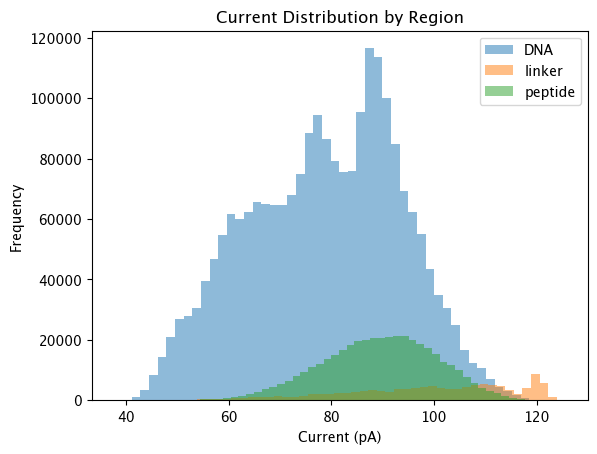

In [4]:
for region in ['DNA', 'linker', 'peptide']:
    subset = db[db['region'] == region]['current_pA']
    plt.hist(subset, bins=50, alpha=0.5, label=region)
    plt.xlabel('Current (pA)')
    plt.ylabel('Frequency')
    plt.title('Current Distribution by Region')
plt.legend()
plt.show()

## **Run Predictions**

In [5]:
accuracies, predictions = run_predictions(model, test_db)

overall_acc = np.mean(list(accuracies.values()))
print(f"Overall accuracy: {overall_acc:.2%}\n")
print(f"{'Trace':>6}  {'Accuracy':>8}")
for tid, acc in sorted(accuracies.items()):
    print(f"  {tid:>6}  {acc:>8.2%}")

Overall accuracy: 88.49%

 Trace  Accuracy
     500    99.46%
     501    97.72%
     502    93.45%
     503    80.16%
     504    98.23%
     505    97.94%
     506    98.43%
     507    49.17%
     508    79.54%
     509    81.11%
     510    83.48%
     511    96.15%
     512    98.87%
     513    99.06%
     514    98.63%
     515    98.94%
     516    95.03%
     517    75.46%
     518    94.36%
     519    96.85%
     520    97.53%
     521    78.38%
     522    82.37%
     523    98.82%
     524    98.87%
     525    95.82%
     526    98.92%
     527    98.30%
     528    76.26%
     529    98.34%
     530    82.56%
     531    98.40%
     532    94.27%
     533    98.25%
     534    84.91%
     535    98.88%
     536    85.94%
     537    42.43%
     538    99.47%
     539    91.77%
     540    97.93%
     541    86.10%
     542    98.24%
     543    39.11%
     544    85.27%
     545    98.73%
     546    79.36%
     547    98.57%
     548    81.44%
     549    82.03%
     55

In [6]:
for tid, acc in sorted(accuracies.items()):
    if acc < 0.9:
        print(f"\nTrace {tid} - Accuracy: {acc:.2%}")


Trace 503 - Accuracy: 80.16%

Trace 507 - Accuracy: 49.17%

Trace 508 - Accuracy: 79.54%

Trace 509 - Accuracy: 81.11%

Trace 510 - Accuracy: 83.48%

Trace 517 - Accuracy: 75.46%

Trace 521 - Accuracy: 78.38%

Trace 522 - Accuracy: 82.37%

Trace 528 - Accuracy: 76.26%

Trace 530 - Accuracy: 82.56%

Trace 534 - Accuracy: 84.91%

Trace 536 - Accuracy: 85.94%

Trace 537 - Accuracy: 42.43%

Trace 541 - Accuracy: 86.10%

Trace 543 - Accuracy: 39.11%

Trace 544 - Accuracy: 85.27%

Trace 546 - Accuracy: 79.36%

Trace 548 - Accuracy: 81.44%

Trace 549 - Accuracy: 82.03%

Trace 552 - Accuracy: 71.94%

Trace 553 - Accuracy: 46.05%

Trace 554 - Accuracy: 86.90%

Trace 561 - Accuracy: 85.21%

Trace 565 - Accuracy: 62.93%

Trace 573 - Accuracy: 83.32%

Trace 575 - Accuracy: 85.96%

Trace 576 - Accuracy: 60.49%

Trace 577 - Accuracy: 81.20%

Trace 581 - Accuracy: 54.39%

Trace 586 - Accuracy: 71.32%

Trace 587 - Accuracy: 59.43%

Trace 589 - Accuracy: 82.40%

Trace 590 - Accuracy: 20.99%

Trace 593

## **Visualize**

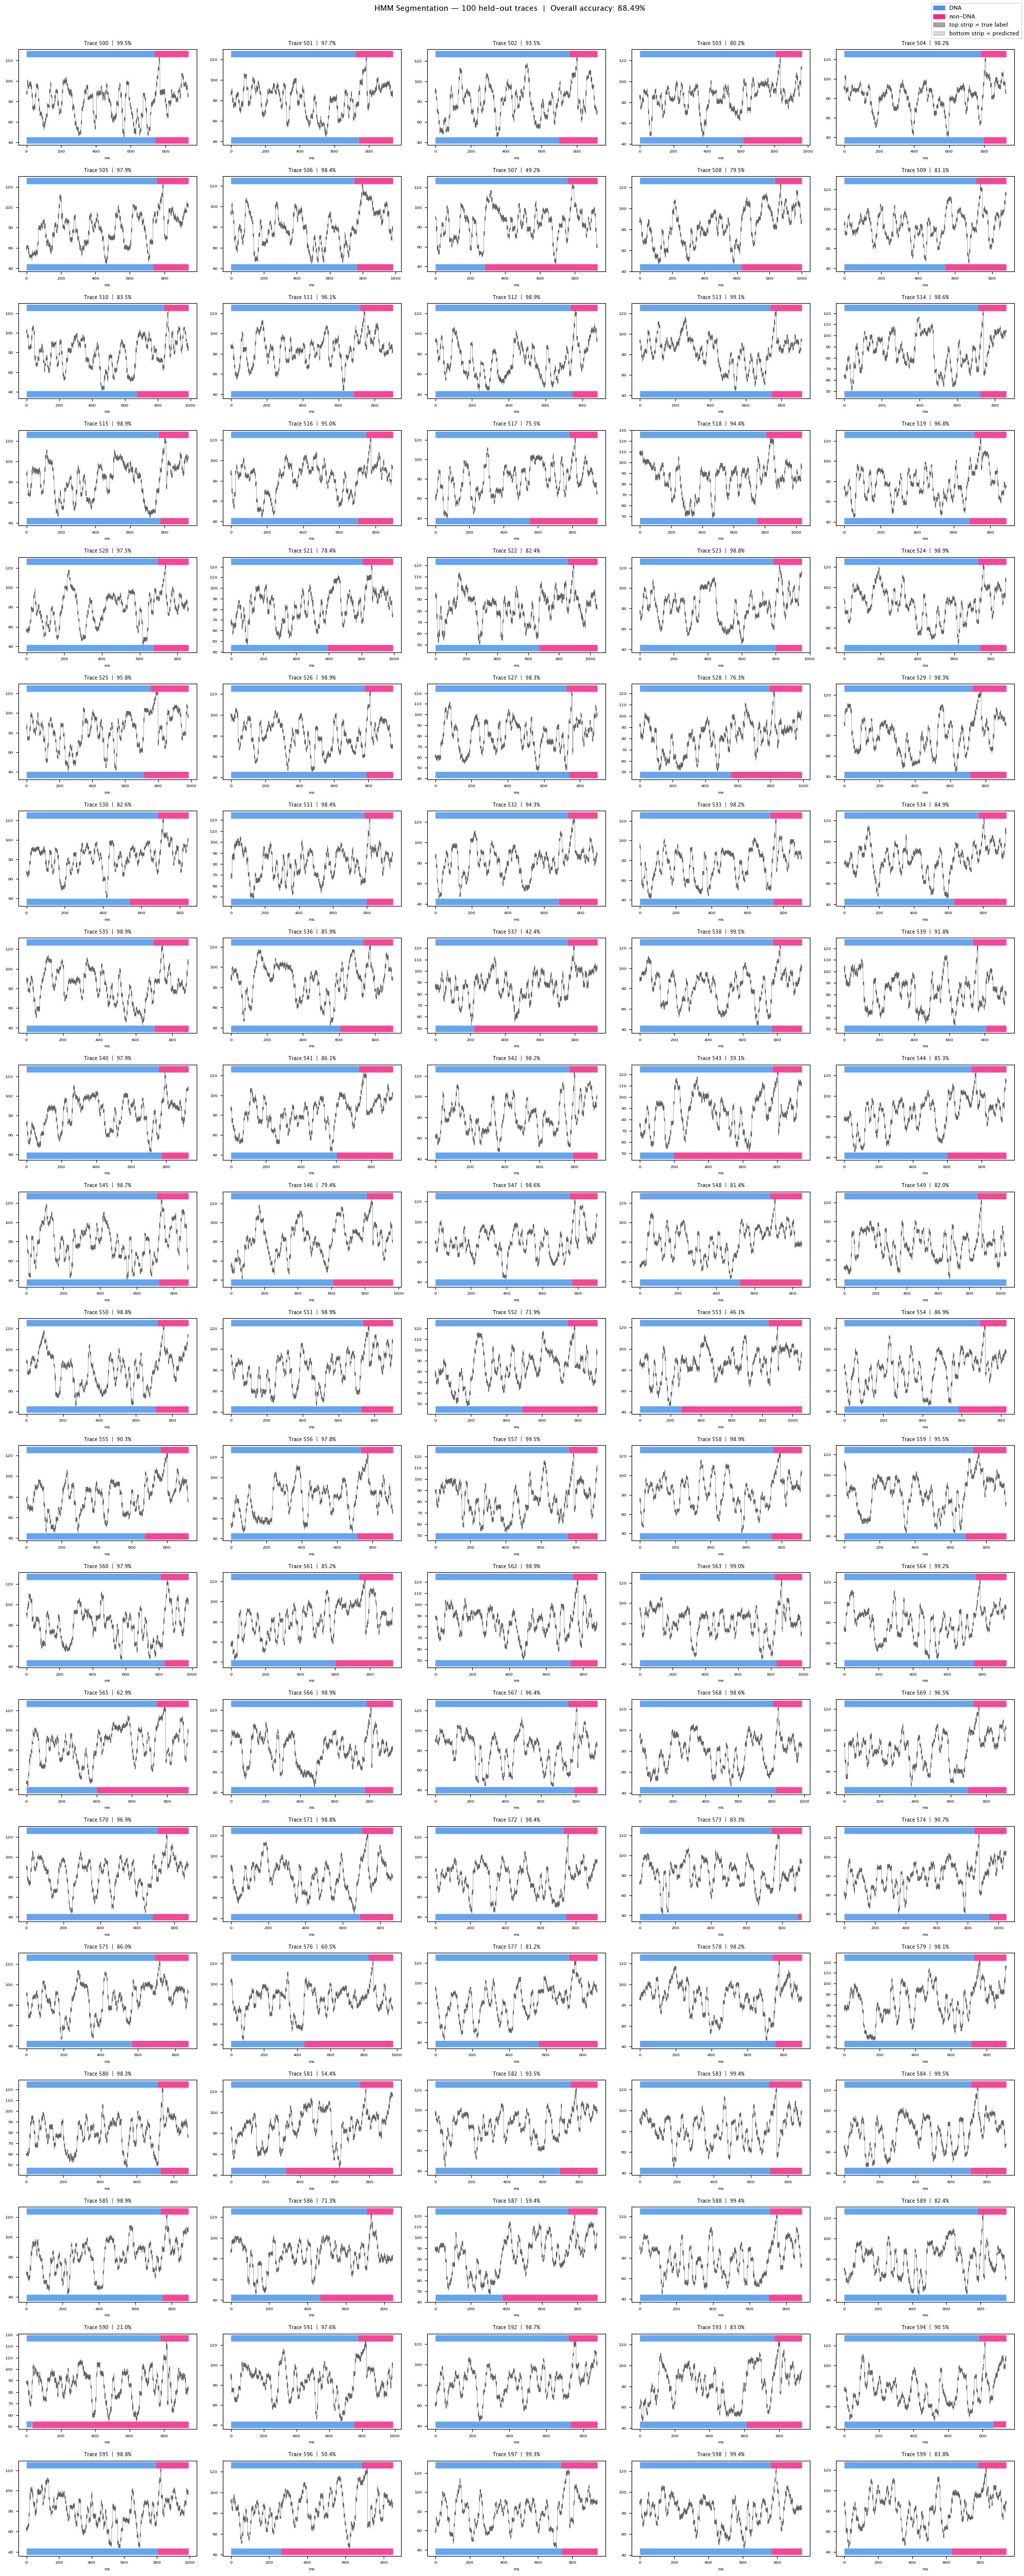

In [7]:
n     = len(predictions)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 2.5), squeeze=False)

for idx, (tid, data) in enumerate(predictions.items()):
    ax = axes[idx // ncols][idx % ncols]
    t, I = data['time_ms'], data['current_pA']

    ymin, ymax = I.min(), I.max()
    band = (ymax - ymin) * 0.08

    shade_regions(ax, t, data['true_states'], ymax,        ymax + band)  # top strip = true
    shade_regions(ax, t, data['pred_states'], ymin - band, ymin)          # bottom strip = predicted

    ax.plot(t, I, color='#222', lw=0.4, alpha=0.7)
    ax.set_ylim(ymin - band * 1.2, ymax + band * 1.2)
    ax.set_title(f'Trace {tid}  |  {accuracies[tid]:.1%}', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlabel('ms', fontsize=6)

for idx in range(n, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

legend_patches  = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches += [
    mpatches.Patch(color='gray', alpha=0.7, label='top strip = true label'),
    mpatches.Patch(color='gray', alpha=0.3, label='bottom strip = predicted'),
]
fig.legend(handles=legend_patches, loc='upper right', fontsize=8)
fig.suptitle(f'HMM Segmentation — {n} held-out traces  |  Overall accuracy: {overall_acc:.2%}',
             fontsize=11, y=1.005)
plt.tight_layout()
plt.show()

In [9]:
import ipywidgets as widgets
from IPython.display import display

trace_ids = list(predictions.keys())

def plot_trace(idx):
    plt.close('all')
    tid = trace_ids[idx]
    data = predictions[tid]
    t, I = data['time_ms'], data['current_pA']

    fig, ax = plt.subplots(figsize=(13, 5))

    shade_regions(ax, t, data['true_states'],  244, 250)   # top
    shade_regions(ax, t, data['pred_states'],  0,   6)     # bottom

    ax.plot(t, I, color='#222', lw=0.4, alpha=0.7)
    ax.set_ylim(0, 250)
    ax.set_title(f'Trace {tid}  |  Accuracy: {accuracies[tid]:.1%}', fontsize=10)
    ax.set_xlabel('ms')

    legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
    legend_patches += [
        mpatches.Patch(color='gray', alpha=0.7, label='top = true'),
        mpatches.Patch(color='gray', alpha=0.3, label='bottom = predicted'),
    ]
    ax.legend(handles=legend_patches, fontsize=13, loc='upper right')
    plt.tight_layout()
    display(fig)
    plt.close(fig)

widgets.interact(plot_trace, idx=widgets.IntSlider(min=0, max=len(trace_ids)-1, step=1, description='Trace'))


interactive(children=(IntSlider(value=0, description='Trace', max=99), Output()), _dom_classes=('widget-intera…

<function __main__.plot_trace(idx)>

Mean boundary error : -89.388 ms
Std  boundary error : 160.165 ms
MAE                 : 106.400 ms
Max early           : -745.400 ms
Max late            : 152.000 ms


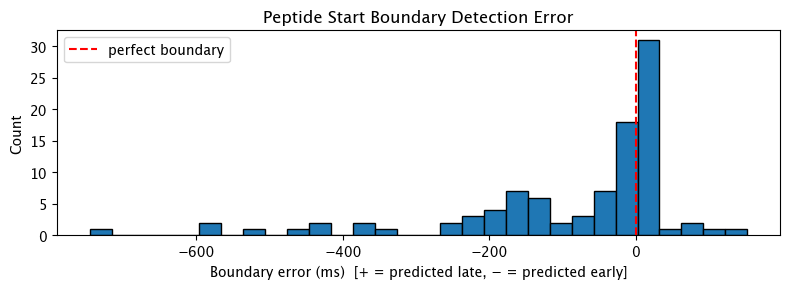

In [10]:
boundary_errors = compute_boundary_errors(predictions)

errors = np.array(list(boundary_errors.values()))
print(f"Mean boundary error : {errors.mean():.3f} ms")
print(f"Std  boundary error : {errors.std():.3f} ms")
print(f"MAE                 : {np.abs(errors).mean():.3f} ms")
print(f"Max early           : {errors.min():.3f} ms")
print(f"Max late            : {errors.max():.3f} ms")

plt.figure(figsize=(8, 3))
plt.hist(errors, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='perfect boundary')
plt.xlabel('Boundary error (ms)  [+ = predicted late, − = predicted early]')
plt.ylabel('Count')
plt.title('Peptide Start Boundary Detection Error')
plt.legend()
plt.tight_layout()
plt.show()

## Test on Real Fast5 Data

In [11]:
import pathlib
import tomllib
import poreflow as pf

with open("parameters.toml", "rb") as f:
    config = tomllib.load(f)

input_cfg = config["input"]
data_path = pathlib.Path(input_cfg["path"]) / input_cfg["file"]
target_sfreq = input_cfg["target_SamplingRate"]

CHANNEL = 18   # change to your channel of interest
EVENT_IDX = 20  # index into events found in this channel

with pf.File(data_path) as f:
    raw = f.get_raw(CHANNEL, downsample=target_sfreq)

events = raw.find_events(**config["event_finding"])
if events is None or len(events) == 0:
    raise RuntimeError(f"No events found in channel {CHANNEL}")
events = events.filter_by_duration()
print(f"Found {len(events)} events in channel {CHANNEL}")

ev = events.iloc[EVENT_IDX]
event_current = raw['i'].values[int(ev['start_idx']):int(ev['end_idx'])]
event_ios     = float(ev['ios'])

print(f"Event {EVENT_IDX}: {len(event_current)} samples | IOS = {event_ios:.1f} pA")
print(f"Current range: {event_current.min():.1f} – {event_current.max():.1f} pA")

FileNotFoundError: [Errno 2] No such file or directory: 'parameters.toml'

In [12]:
t_ms = np.arange(len(event_current)) * (1000 / target_sfreq)

X = event_current.reshape(-1, 1)
pred_states = model.predict(X)

fig, ax = plt.subplots(figsize=(14, 3))
ymin, ymax = event_current.min(), event_current.max()
band = (ymax - ymin) * 0.08

shade_regions(ax, t_ms, pred_states, ymin - band, ymin)
ax.plot(t_ms, event_current, color='#222', lw=0.4, alpha=0.8)
ax.axhline(event_ios, color='orange', linestyle='--', lw=1, label=f'IOS = {event_ios:.0f} pA')

ax.set_ylim(ymin - band * 1.2, ymax + band * 1.2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Current (pA)')
ax.set_title(f'HMM Segmentation — Channel {CHANNEL}, Event {EVENT_IDX}')

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches.append(mpatches.Patch(color='orange', label=f'IOS = {event_ios:.0f} pA'))
ax.legend(handles=legend_patches, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print("Predicted region fractions:")
for state, region in STATE_TO_REGION.items():
    print(f"  {region:>8}: {np.mean(pred_states == state):.1%}")

NameError: name 'event_current' is not defined

In [13]:
t_ms = np.arange(len(event_current)) * (1000 / target_sfreq)

plt.figure(figsize=(14, 3))
plt.plot(t_ms, event_current, lw=0.5, color='#222')
plt.xlabel('Time (ms)')
plt.ylabel('Current (pA)')
plt.title(f'Channel {CHANNEL} — Event {EVENT_IDX}')
plt.tight_layout()
plt.show()

NameError: name 'event_current' is not defined

In [22]:
print(f"Current range: {event_current.min():.1f} – {event_current.max():.1f} pA")
print(f"Event duration: {len(event_current) / target_sfreq:.2f} s")
print(f"IOS: {event_ios:.1f} pA")

Current range: 8.7 – 248.3 pA
Event duration: 1.61 s
IOS: 256.3 pA
